In [ ]:
#this code adds receding horizon with 72 hours horizon and optimization every 24 hours. 

import numpy as np
import gurobipy as gp
from gurobipy import GRB
from gurobipy import quicksum
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import os

from functions import (plot_DA_week,
                    load_da_market_data,
                    load_fcr_prices,
                    plot_fcr_prices)

In [4]:
#Battery Parameters
battery_capacity = 40 #[MWh]
SOC_min = 1 #[Mwh]
charge_rate_min = 0 #[MW]
discharge_rate_min = 0 #[MW]
charge_rate_max = 10 #[MW]
discharge_rate_max = 10 #[MW]
efficiency = 0.99
self_discharge_rate = 0
initial_SOC = 20 #[MWh]

#Market Parameters:
    #DAM:
minimum_bid_DAM = 0.1 #[MW]
granularity_DAM = 1 #hours

In [5]:
# Load Day-Ahead Market Prices
da_folder = "data/energy-charts_day_ahead"
years_to_load = [2024]  # available years span 2015-2024

# Load Day-Ahead Market Prices
DA_prices_merged = load_da_market_data(da_folder, years_to_load)
DA_prices_merged["timestamp"] = pd.to_datetime(DA_prices_merged["timestamp"])
DA_prices_merged["timestamp"] = DA_prices_merged["timestamp"] + pd.Timedelta(hours=1) # shift by one hour to fit local time
DA_prices_merged = DA_prices_merged.sort_values("timestamp").reset_index(drop=True)
DA_prices_merged["delivery_day"] = DA_prices_merged["timestamp"].dt.floor("D") # create delivery day column

print(f"Loaded {len(DA_prices_merged)} hourly day-ahead price points.")
print(DA_prices_merged.head())

Loaded 8784 hourly day-ahead price points.
                  timestamp  price_eur_mwh              delivery_day
0 2024-01-01 00:00:00+00:00          25.97 2024-01-01 00:00:00+00:00
1 2024-01-01 01:00:00+00:00          21.99 2024-01-01 00:00:00+00:00
2 2024-01-01 02:00:00+00:00          14.32 2024-01-01 00:00:00+00:00
3 2024-01-01 03:00:00+00:00          11.37 2024-01-01 00:00:00+00:00
4 2024-01-01 04:00:00+00:00          11.35 2024-01-01 00:00:00+00:00


In [ ]:
def solve_day_ahead(
    prices_block,
    initial_soc,
    *,
    granularity_hours=1,
    battery_capacity=40.0,
    soc_min=1.0,
    charge_rate_bounds=(0.0, 10.0),
    discharge_rate_bounds=(0.0, 10.0),
    efficiency=0.99,
    self_discharge_rate=0.0,
    minimum_bid_volume=0.1,   
    n_bid_slots=10,           
    time_limit_seconds=60,
    gurobi_output=False,
    terminal_soc_target=None,
):
    """
    Solve day-ahead battery dispatch optimization problem.
    """
    
    clearing_price = prices_block["price_eur_mwh"].to_numpy(dtype=float)
    if len(clearing_price) == 0:
        raise ValueError("No price data provided for the horizon.")
    horizon = list(range(len(clearing_price)))  # power slots
    soc_slots = list(range(len(clearing_price) + 1))  # SOC slots (+1)

    MMO = gp.Model("DA_dispatch")
    MMO.Params.OutputFlag = 1 if gurobi_output else 0
    MMO.Params.TimeLimit = time_limit_seconds

    charge_lb, charge_ub = charge_rate_bounds
    discharge_lb, discharge_ub = discharge_rate_bounds

    # ===============================
    # VARIABLES
    # ===============================
    Charge = MMO.addVars(horizon, vtype=GRB.CONTINUOUS, lb=charge_lb, ub=charge_ub, name="Battery_Charge")
    Discharge = MMO.addVars(horizon, vtype=GRB.CONTINUOUS, lb=discharge_lb, ub=discharge_ub, name="Battery_Discharge")
    ChargingIndicator = MMO.addVars(horizon, vtype=GRB.BINARY, name="Charging_Indicator")

    SOC = MMO.addVars(
        soc_slots, vtype=GRB.CONTINUOUS, lb=soc_min, ub=battery_capacity, name="Battery_State_Of_Charge"
    )

    # ===============================
    # CONSTRAINTS
    # ===============================
    MMO.addConstr(SOC[0] == initial_soc)

    # SOC dynamic balance
    for t in horizon:
        MMO.addConstr(
            SOC[t + 1]
            == (1 - self_discharge_rate) * SOC[t]
            + granularity_hours * (efficiency * Charge[t] - (1 / efficiency) * Discharge[t])
        )

    # Terminal SOC
    if terminal_soc_target is not None:
        MMO.addConstr(SOC[soc_slots[-1]] == terminal_soc_target)

    # Prevent simultaneous charging/discharging
    for t in horizon:
        MMO.addGenConstrIndicator(ChargingIndicator[t], True, Discharge[t] == 0)
        MMO.addGenConstrIndicator(ChargingIndicator[t], False, Charge[t] == 0)

    # ===============================
    # OBJECTIVE
    # ===============================
    profit = quicksum(
        clearing_price[t] * (Discharge[t] - Charge[t]) * granularity_hours for t in horizon
    )

    MMO.setObjective(profit, GRB.MAXIMIZE)
    MMO.optimize()

    if MMO.Status not in {GRB.OPTIMAL, GRB.TIME_LIMIT}:
        raise RuntimeError(f"Model ended with status {MMO.Status}")

    # ===============================
    # OUTPUT
    # ===============================
    schedule = {
        "charge": np.array([Charge[t].X for t in horizon]),
        "discharge": np.array([Discharge[t].X for t in horizon]),
        "soc": np.array([SOC[t].X for t in soc_slots]),
    }

    return {
        "status": MMO.Status,
        "objective_value": MMO.ObjVal if MMO.SolCount else None,
        "schedule": schedule,
        "terminal_soc": schedule["soc"][-1],
    }


In [ ]:
# =====================================================
# RECEDING HORIZON OPTIMIZATION (72h look-ahead, 24h apply)
# =====================================================

look_ahead_hours = 72  # 3 days, each optimization looks at 72 hours of price
apply_hours = 24       # 1 day
granularity_hours = granularity_DAM

timestamps = DA_prices_merged["timestamp"]
start_time = timestamps.min() #first timestamp
end_time = timestamps.max() #last timestamp

state_soc = initial_SOC 
current_time = start_time #initialize current time

hourly_rows = [] 
daily_rows = []

while current_time + pd.Timedelta(hours=apply_hours) <= end_time: #loop 24h at a time until we reach the end of the data
    # Select look-ahead window (next 72 hours)
    horizon_end = current_time + pd.Timedelta(hours=look_ahead_hours)
    block = DA_prices_merged[
        (DA_prices_merged["timestamp"] >= current_time)
        & (DA_prices_merged["timestamp"] < horizon_end)
    ].copy() #select block of price data for the horizon

    if len(block) == 0:
        print(f"Skipping {current_time.date()} — no data available.")
        current_time += pd.Timedelta(hours=apply_hours)
        continue

    # Set target SOC only for the final horizon
    target_soc = initial_SOC if horizon_end >= end_time else None

    # Solve the optimization for the next 72 hours
    result = solve_day_ahead(
        block,
        state_soc,
        granularity_hours=granularity_hours,
        battery_capacity=battery_capacity,
        soc_min=SOC_min,
        charge_rate_bounds=(charge_rate_min, charge_rate_max),
        discharge_rate_bounds=(discharge_rate_min, discharge_rate_max),
        efficiency=efficiency,
        self_discharge_rate=self_discharge_rate,
        minimum_bid_volume=minimum_bid_DAM,
        n_bid_slots=10,
        terminal_soc_target=target_soc,
        time_limit_seconds=60,
        gurobi_output=False,
    )

    # Extract schedule for 72 hours
    schedule = result["schedule"] #dictionary that contains charge, discharge, soc profiles
    soc_profile = schedule["soc"]
    charge = schedule["charge"]
    discharge = schedule["discharge"]

    # Apply only first 24 hours
    n_apply = int(apply_hours / granularity_hours) #number of time slots to apply
    n_opt = len(charge) #number of time slots in optimization
    effective_hours = min(n_apply, n_opt) #effective hours to apply, should be 24 hours unless at the end of the data

    block_apply = block.iloc[:effective_hours].copy() # block of prices for applied hours: first 24 hours

    # Record hourly results, but only for the first 24 hours
    for t in range(effective_hours):
        ts = block_apply["timestamp"].iloc[t]
        hourly_rows.append(
            {
                "timestamp": ts,
                "charge_mw": charge[t],
                "discharge_mw": discharge[t],
                "soc_mwh": soc_profile[t + 1],
                "soc_start_mwh": soc_profile[t],
                "price_eur_mwh": block_apply["price_eur_mwh"].iloc[t],
            }
        )

    # Compute daily profit for applied window
    net_export = np.array(discharge[:effective_hours]) - np.array(charge[:effective_hours])
    realized_profit = float(np.dot(block_apply["price_eur_mwh"].to_numpy(), net_export) * granularity_hours)

    daily_rows.append(
        {
            "run_time": current_time,
            "delivery_day": block_apply["timestamp"].iloc[0].floor("D"),
            "profit_model": result["objective_value"], 
            "profit_recomputed": realized_profit, #net profit
            "terminal_soc": soc_profile[effective_hours],
        }
    )

    # Update SOC for next optimization (use SOC after applied hours)
    state_soc = soc_profile[effective_hours]

    # Rolls horizon forward by one day
    current_time += pd.Timedelta(hours=apply_hours)

# Compile results
profit_df = pd.DataFrame(daily_rows).sort_values("run_time").reset_index(drop=True)
dispatch_df = pd.DataFrame(hourly_rows).sort_values("timestamp").reset_index(drop=True)
annual_profit = profit_df["profit_recomputed"].sum()

print(f"Simulated {len(profit_df)} receding horizon steps.")
print(f"Cumulative DA profit: {annual_profit:,.2f} €")

profit_df.head()

Simulated 365 receding horizon steps.
Cumulative DA profit: 844,839.53 €


,run_time,delivery_day,profit_model,profit_recomputed,terminal_soc
0,2024-01-01 00:00:00+00:00,2024-01-01 00:00:00+00:00,6982.762549,1833.295350,1.0
1,2024-01-02 00:00:00+00:00,2024-01-02 00:00:00+00:00,8017.843327,2145.443248,10.9
2,2024-01-03 00:00:00+00:00,2024-01-03 00:00:00+00:00,7079.200067,3004.158254,1.0
3,2024-01-04 00:00:00+00:00,2024-01-04 00:00:00+00:00,4839.976761,2868.241824,1.0
4,2024-01-05 00:00:00+00:00,2024-01-05 00:00:00+00:00,3143.155740,1206.799988,1.0


## Extract Results

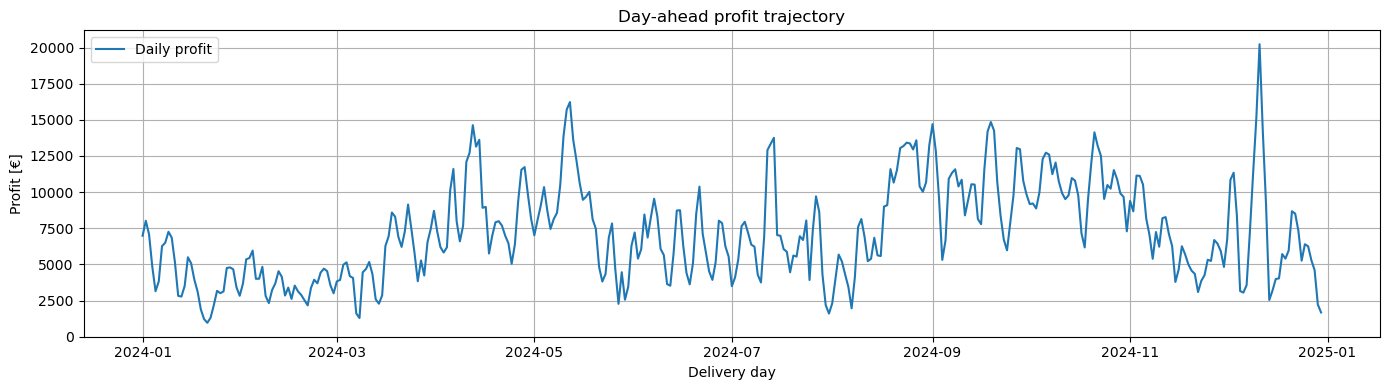

In [13]:
if profit_df.empty:
    print("No results to plot.")
else:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(profit_df["delivery_day"], profit_df["profit_model"], label="Daily profit")
    ax.set_ylabel("Profit [€]")
    ax.set_xlabel("Delivery day")
    ax.grid(True)
    ax.set_title("Day-ahead profit trajectory")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [14]:
def plot_dispatch(dispatch_df, *, week=None, day=None, start=None, end=None,
                  tz="UTC", view_tz="Europe/Zurich"):
    """
    Select one: week=<int>, day=<YYYY-MM-DD>, or start/end window.
    """
    if dispatch_df.empty:
        print("No dispatch trajectories available.")
        return

    modes = [week is not None, day is not None, (start is not None and end is not None)]
    if sum(modes) != 1:
        raise ValueError("Specify exactly one of `week`, `day`, or (`start`, `end`).")

    ts = pd.to_datetime(dispatch_df["timestamp"])
    if ts.dt.tz is None and tz:
        ts = ts.dt.tz_localize(tz)

    def to_view_local(series):
        return series.dt.tz_convert(view_tz).dt.tz_localize(None) if view_tz else series.tz_localize(None)

    if start is not None:
        start = pd.to_datetime(start)
        end = pd.to_datetime(end)
        if ts.dt.tz is not None:
            start = start.tz_localize(ts.dt.tz)
            end = end.tz_localize(ts.dt.tz)
        mask = (ts >= start) & (ts <= end)
        label = f"{start} → {end}"
    elif day is not None:
        day = pd.to_datetime(day)
        local_series = to_view_local(ts)
        mask = local_series.dt.normalize() == day.normalize()
        label = f"Day {day.date()}"
    else:
        hours_per_week = 24 * 7
        start_idx = (week - 1) * hours_per_week
        end_idx = start_idx + hours_per_week
        if end_idx > len(dispatch_df):
            print(f"Not enough data to plot week {week}. Available hours: {len(dispatch_df)}")
            return
        slice_df = dispatch_df.iloc[start_idx:end_idx]
        local_time = to_view_local(pd.to_datetime(slice_df["timestamp"]))
        return _plot_slice(slice_df.reset_index(drop=True), local_time, label=f"Week {week}")

    slice_df = dispatch_df.loc[mask]
    if slice_df.empty:
        print(f"No data found for the selected window ({label}).")
        return

    slice_df = slice_df.sort_values("timestamp").reset_index(drop=True)
    local_time = to_view_local(pd.to_datetime(slice_df["timestamp"]))
    _plot_slice(slice_df, local_time, label)


def _plot_slice(slice_df, local_time, label):
    charge = slice_df["charge_mw"]
    discharge = slice_df["discharge_mw"]
    soc = slice_df["soc_mwh"]
    price = slice_df["price_eur_mwh"]

    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axs[0].fill_between(local_time, 0, charge, step='mid', alpha=0.4, color='blue', label='Charge [MW]')
    axs[0].fill_between(local_time, 0, -discharge, step='mid', alpha=0.4, color='red', label='Discharge [MW]')
    axs[0].plot(local_time, soc, color='black', linewidth=2, label='SOC [MWh]')
    axs[0].set_ylabel("Power [MW] / SoC [MWh]")
    axs[0].legend(loc='upper left')
    axs[0].grid(True)
    axs[0].set_title(f"Optimal BESS Schedule — {label}")

    axs[1].plot(local_time, price, color='green', linewidth=1.8)
    axs[1].set_ylabel("DA Price [€/MWh]")
    axs[1].grid(True)
    axs[1].set_xlabel(f"Time ({local_time.iloc[0].tzname() if hasattr(local_time.iloc[0], 'tzinfo') else 'local'})")

    plt.tight_layout()
    plt.show()



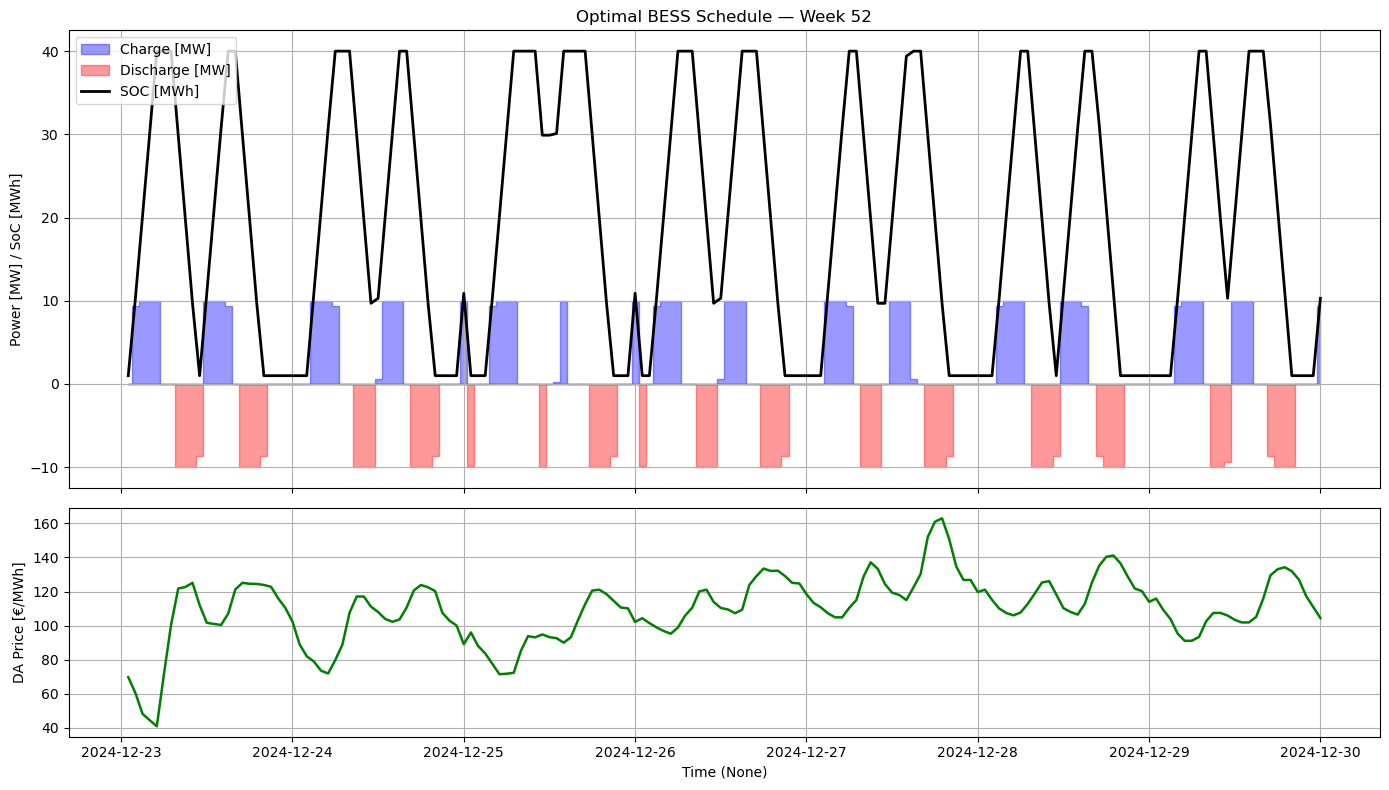

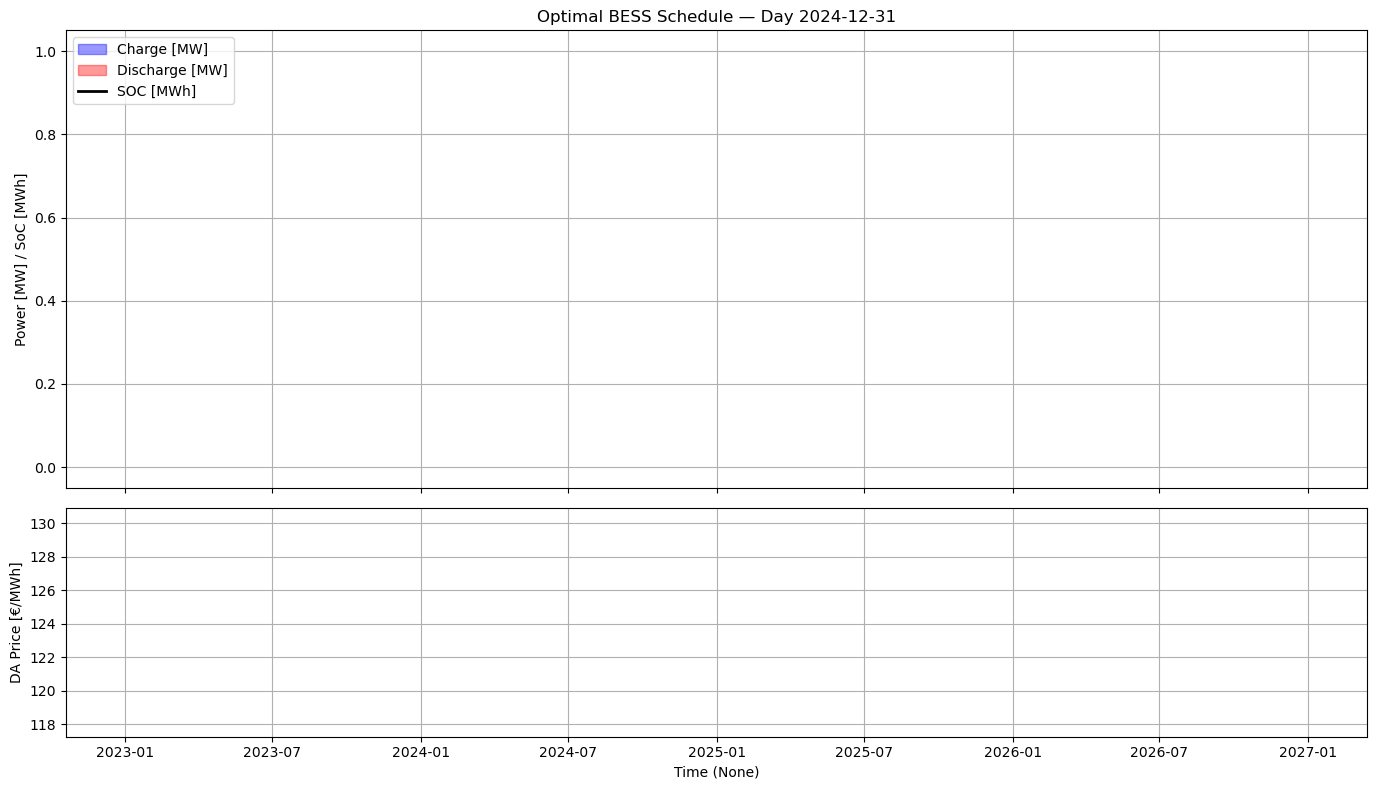

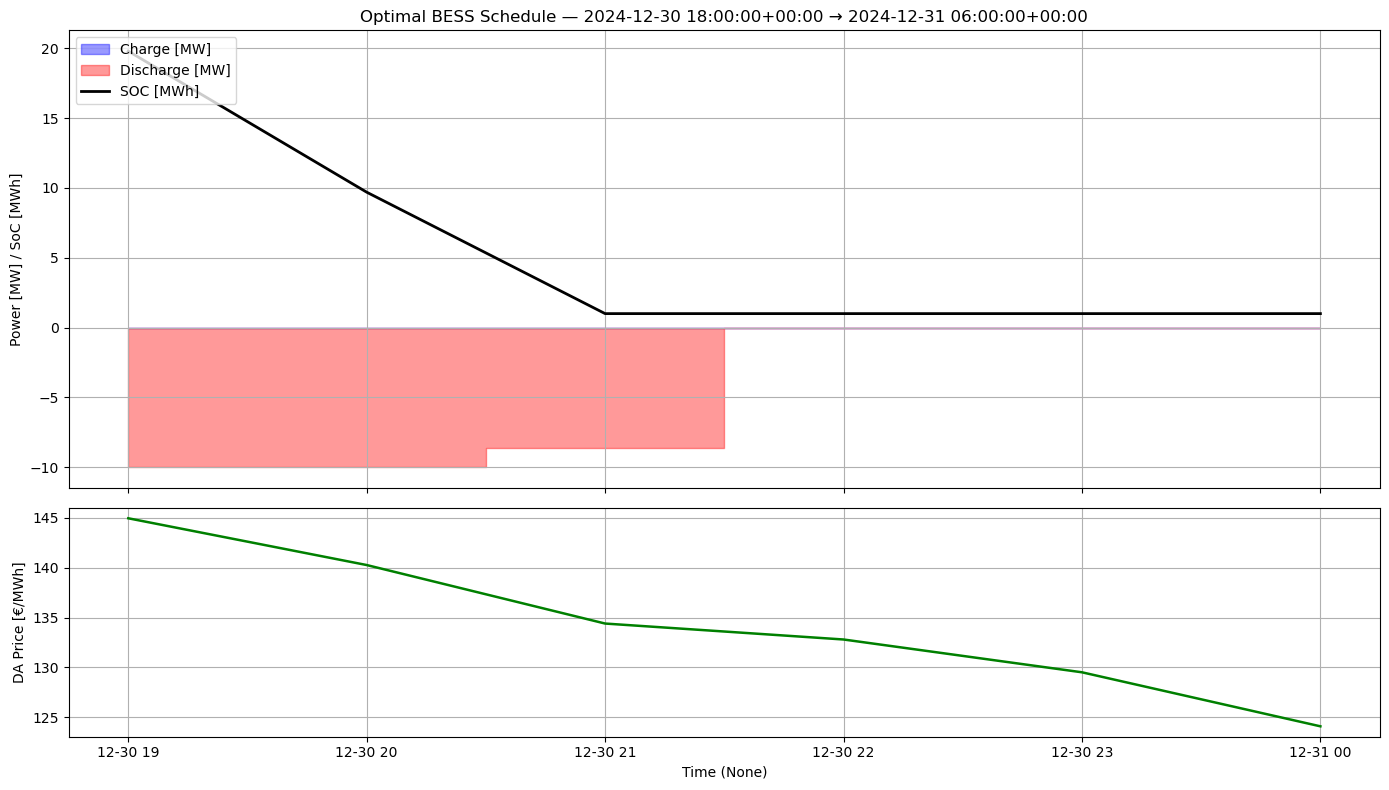

In [15]:
plot_dispatch(dispatch_df, week=52)
plot_dispatch(dispatch_df, day="2024-12-31")
plot_dispatch(dispatch_df, start="2024-12-30 18:00", end="2024-12-31 06:00")